## Wikipedia Labels × ACLED Control Signals — Validation Notebook

**Goal:** Check whether the Wikipedia territorial control labels agree with what ACLED independently observed in the same cell, time window, and actor dimension.

Five analyses in order of importance:
1. **Actor-side purity** — for each Wikipedia label, what fraction of ACLED events came from Pro-junta vs Anti-junta?
2. **Control signal placement** — do ACLED territorial transfer events cluster in Wikipedia-contested cells?
3. **Temporal consistency** — when Wikipedia changes a label between snapshots, was ACLED already showing increased conflict in the preceding months?
4. **Admin1 regional alignment** — do Wikipedia label distributions match ACLED actor dominance by state/region?
5. **Actor confusion matrix** — given the dominant ACLED actor_group in a cell-month, what does Wikipedia say?

**Data used:**
- `notebook_training/checkpoints/myanmar_acled_grouped.parquet` — ACLED with `side`, `coalition`, `actor_group` from notebook 00
- `data/processed/myanmar_priogrid_labels.csv` — Wikipedia labels projected to PRIOGRID cells (step 9 output)
- `data/raw/validation/myanmar_wikipedia_temporal_groundtruth.csv` — raw Wikipedia point-level labels with actor strings

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 120)

# ── Paths ──────────────────────────────────────────────────────
ACLED_PATH  = Path('../checkpoints/myanmar_acled_grouped.parquet')
WIKI_CELL   = Path('../../data/processed/myanmar_priogrid_labels.csv')
WIKI_RAW    = Path('../../data/raw/validation/myanmar_wikipedia_temporal_groundtruth.csv')

# ── Colour schemes (consistent with notebooks 00 & step 4–6) ───
WIKI_COLOURS = {
    'government':          '#CC3333',
    'resistance':          '#33AA44',
    'ethnic_armed_group':  '#2266CC',
    'contested':           '#FF9900',
    'unknown':             '#999999',
}
SIDE_COLOURS = {
    'Pro-junta':                  '#CC3333',
    'Anti-junta':                 '#3399CC',
    'Neutral / Self-administered':'#AAAAAA',
    'Other / Unmapped':           '#DDDDDD',
}

# ── PRIOGRID formula (identical to step 9) ─────────────────────
def latlon_to_priogrid_gid(lat, lon):
    row = int((lat + 90) / 0.5) + 1
    col = int((lon + 180) / 0.5) + 1
    return (row - 1) * 720 + col

print('Setup complete.')

Setup complete.


## 2. Load Data

In [2]:
# ── ACLED: post-coup only, within Wikipedia coverage window ────
acled_raw = pd.read_parquet(ACLED_PATH)
acled_raw['event_date'] = pd.to_datetime(acled_raw['event_date'])

COUP_DATE  = pd.Timestamp('2021-02-01')
WIKI_START = pd.Timestamp('2023-11-01')   # first Wikipedia snapshot
WIKI_END   = pd.Timestamp('2026-03-31')   # last Wikipedia snapshot

acled = acled_raw[
    (acled_raw['event_date'] >= WIKI_START) &
    (acled_raw['event_date'] <= WIKI_END)
].copy()

# Assign PRIOGRID cell and year_month
acled['priogrid_gid'] = acled.apply(
    lambda r: latlon_to_priogrid_gid(r['latitude'], r['longitude']), axis=1
)
acled['year_month'] = acled['event_date'].dt.to_period('M').astype(str)

print(f'ACLED (overlap window): {len(acled):,} events  |  '
      f'{acled["event_date"].min().date()} → {acled["event_date"].max().date()}')
print(f'Side distribution:')
print(acled['side'].value_counts().to_string())

# ── Wikipedia cell-level labels ────────────────────────────────
wiki = pd.read_csv(WIKI_CELL)
print(f'\nWikipedia cell labels: {len(wiki):,} rows  |  '
      f'{wiki["year_month"].min()} → {wiki["year_month"].max()}')
print(wiki['control_status'].value_counts().to_string())

# ── Wikipedia raw point-level (for actor string detail) ────────
wiki_raw = pd.read_csv(WIKI_RAW)
wiki_raw['date'] = pd.to_datetime(wiki_raw['date'])
wiki_raw['year_month'] = wiki_raw['date'].dt.to_period('M').astype(str)
wiki_raw['priogrid_gid'] = wiki_raw.apply(
    lambda r: latlon_to_priogrid_gid(r['lat'], r['lon']), axis=1
)
print(f'\nWikipedia raw points: {len(wiki_raw):,} rows')

ACLED (overlap window): 39,348 events  |  2023-11-01 → 2026-03-31
Side distribution:
side
Pro-junta                      22829
Anti-junta                     10477
Other / Unmapped                5964
Neutral / Self-administered       78

Wikipedia cell labels: 5,238 rows  |  2023-11 → 2026-03
control_status
government            3323
contested              891
ethnic_armed_group     613
resistance             411

Wikipedia raw points: 8,035 rows


## 3. Build the Joined Panel

Aggregate ACLED to cell × month, then join with Wikipedia labels. Each row in the panel has both the Wikipedia label and the ACLED signal for the same cell-month.

In [3]:
# ── Aggregate ACLED to cell × month ───────────────────────────
# For each cell-month: total events, events per side, control signals

# Side event counts (pivot)
side_counts = (
    acled.groupby(['priogrid_gid', 'year_month', 'side'])
         .size()
         .unstack(fill_value=0)
         .reset_index()
)
# Ensure all side columns exist
for s in ['Pro-junta', 'Anti-junta', 'Neutral / Self-administered', 'Other / Unmapped']:
    if s not in side_counts.columns:
        side_counts[s] = 0

# Actor_group dominant (most events in cell-month)
dominant_actor = (
    acled[acled['side'].isin(['Pro-junta', 'Anti-junta', 'Neutral / Self-administered'])]
         .groupby(['priogrid_gid', 'year_month', 'actor_group'])
         .size()
         .reset_index(name='n')
         .sort_values('n', ascending=False)
         .drop_duplicates(subset=['priogrid_gid', 'year_month'])
         [['priogrid_gid', 'year_month', 'actor_group']]
         .rename(columns={'actor_group': 'dominant_actor_group'})
)

# Control signal events per cell-month
ctrl_signals = (
    acled.groupby(['priogrid_gid', 'year_month'])
         .agg(
             total_events     = ('event_id_cnty', 'count'),
             control_signals  = ('is_control_signal', 'sum'),
             total_fatalities = ('fatalities', 'sum'),
             admin1           = ('admin1', 'first'),
         )
         .reset_index()
)

# Merge ACLED aggregates together
acled_agg = (
    ctrl_signals
    .merge(side_counts[['priogrid_gid', 'year_month',
                         'Pro-junta', 'Anti-junta',
                         'Neutral / Self-administered', 'Other / Unmapped']],
           on=['priogrid_gid', 'year_month'], how='left')
    .merge(dominant_actor, on=['priogrid_gid', 'year_month'], how='left')
)

# Derived: shares
acled_agg['pct_projunta']  = acled_agg['Pro-junta']   / acled_agg['total_events'].clip(lower=1)
acled_agg['pct_antijunta'] = acled_agg['Anti-junta']  / acled_agg['total_events'].clip(lower=1)
acled_agg['has_both_sides'] = (
    (acled_agg['Pro-junta'] > 0) & (acled_agg['Anti-junta'] > 0)
)

# ── Join with Wikipedia labels ─────────────────────────────────
panel = wiki.merge(
    acled_agg, on=['priogrid_gid', 'year_month'], how='left'
)
panel[['total_events', 'control_signals', 'Pro-junta', 'Anti-junta']] = (
    panel[['total_events', 'control_signals', 'Pro-junta', 'Anti-junta']].fillna(0)
)
panel['has_acled'] = panel['total_events'] > 0

print(f'Joined panel: {len(panel):,} cell-months')
print(f'With ACLED events: {panel["has_acled"].sum():,}  '
      f'({panel["has_acled"].mean():.1%})')
print(f'Without ACLED events (quiet months): {(~panel["has_acled"]).sum():,}  '
      f'({(~panel["has_acled"]).mean():.1%})')
print()
print('Wikipedia label coverage in panel:')
print(panel['control_status'].value_counts().to_string())

Joined panel: 5,238 cell-months
With ACLED events: 3,398  (64.9%)
Without ACLED events (quiet months): 1,840  (35.1%)

Wikipedia label coverage in panel:
control_status
government            3323
contested              891
ethnic_armed_group     613
resistance             411


## 4. Analysis 1 — Actor-Side Purity by Wikipedia Label

For each Wikipedia control_status, compute the average share of ACLED events from each `side`.  
Expected pattern: `government` → Pro-junta dominant; `resistance` → Anti-junta/PDF dominant; `ethnic_armed_group` → Anti-junta named EAO dominant; `contested` → both sides active.

In [4]:
# ── Only rows that have ACLED events ──────────────────────────
has_events = panel[panel['has_acled']].copy()

side_cols = ['Pro-junta', 'Anti-junta', 'Neutral / Self-administered', 'Other / Unmapped']

# Mean share per Wikipedia label
purity = (
    has_events.groupby('control_status')[side_cols + ['total_events']]
              .mean()
              .round(3)
)
# Normalise to sum to 1 across side columns only
purity_norm = purity[side_cols].div(purity[side_cols].sum(axis=1), axis=0)

print('Mean event-share per side, by Wikipedia label (normalised):')
print(purity_norm.to_string())
print()
print('Mean ACLED events per cell-month, by Wikipedia label:')
print(purity['total_events'].to_string())

Mean event-share per side, by Wikipedia label (normalised):
                    Pro-junta  Anti-junta  Neutral / Self-administered  Other / Unmapped
control_status                                                                          
contested            0.530624    0.266907                     0.000069          0.202400
ethnic_armed_group   0.681343    0.231701                     0.013209          0.073748
government           0.593427    0.259801                     0.001755          0.145017
resistance           0.651101    0.277680                     0.000000          0.071219

Mean ACLED events per cell-month, by Wikipedia label:
control_status
contested             14.418
ethnic_armed_group     7.268
government            10.254
resistance             6.810


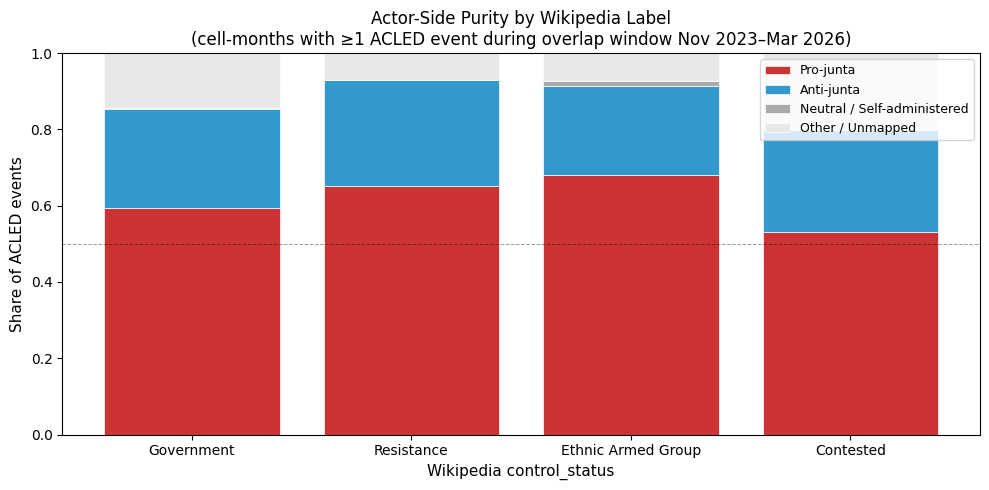


Interpretation guide:
  government cells  → expect Pro-junta (red) to dominate
  resistance cells  → expect Anti-junta (blue) to dominate
  ethnic_arm. cells → expect Anti-junta (blue) to dominate
  contested cells   → expect roughly equal split


In [5]:
# ── Static stacked bar chart ───────────────────────────────────
label_order = ['government', 'resistance', 'ethnic_armed_group', 'contested']
purity_plot = purity_norm.reindex(label_order)

fig, ax = plt.subplots(figsize=(10, 5))
bottoms = np.zeros(len(label_order))
bar_colours = [
    '#CC3333',   # Pro-junta
    '#3399CC',   # Anti-junta
    '#AAAAAA',   # Neutral
    '#E8E8E8',   # Other/Unmapped
]
for col, colour in zip(side_cols, bar_colours):
    vals = purity_plot[col].values
    ax.bar(label_order, vals, bottom=bottoms, color=colour, label=col, edgecolor='white', linewidth=0.5)
    bottoms += vals

ax.set_xlabel('Wikipedia control_status', fontsize=11)
ax.set_ylabel('Share of ACLED events', fontsize=11)
ax.set_title('Actor-Side Purity by Wikipedia Label\n'
             '(cell-months with ≥1 ACLED event during overlap window Nov 2023–Mar 2026)',
             fontsize=12)
ax.set_ylim(0, 1)
ax.legend(loc='upper right', fontsize=9, framealpha=0.8)
ax.axhline(0.5, color='black', linewidth=0.7, linestyle='--', alpha=0.4)
ax.set_xticklabels([l.replace('_', ' ').title() for l in label_order], fontsize=10)
plt.tight_layout()
plt.show()

print('\nInterpretation guide:')
print('  government cells  → expect Pro-junta (red) to dominate')
print('  resistance cells  → expect Anti-junta (blue) to dominate')
print('  ethnic_arm. cells → expect Anti-junta (blue) to dominate')
print('  contested cells   → expect roughly equal split')

In [6]:
# ── Both-sides presence in contested vs non-contested ─────────
print('Fraction of cell-months with BOTH Pro-junta AND Anti-junta events present:')
both_sides = (
    has_events.groupby('control_status')['has_both_sides']
              .mean()
              .reindex(label_order)
)
for label, val in both_sides.items():
    bar = '█' * int(val * 30)
    print(f'  {label:<22} {val:.1%}  {bar}')

print()
print('Pro-junta event share distribution (median / p25 / p75) by Wikipedia label:')
for label in label_order:
    sub = has_events[has_events['control_status'] == label]['pct_projunta']
    print(f'  {label:<22}  median={sub.median():.2f}  '
          f'p25={sub.quantile(0.25):.2f}  p75={sub.quantile(0.75):.2f}  n={len(sub):,}')

Fraction of cell-months with BOTH Pro-junta AND Anti-junta events present:
  government             51.1%  ███████████████
  resistance             40.5%  ████████████
  ethnic_armed_group     37.8%  ███████████
  contested              66.6%  ███████████████████

Pro-junta event share distribution (median / p25 / p75) by Wikipedia label:
  government              median=0.67  p25=0.33  p75=1.00  n=2,118
  resistance              median=0.67  p25=0.38  p75=1.00  n=274
  ethnic_armed_group      median=0.69  p25=0.00  p75=1.00  n=209
  contested               median=0.56  p25=0.30  p75=0.78  n=797


## 5. Analysis 2 — Control Signal Placement

ACLED `is_control_signal` events (`Non-state actor overtakes territory`, `Government regains territory`, etc.) should cluster in cells that Wikipedia labels as `contested`.  
Also checks whether Wikipedia-contested cells had more territorial transfer events than stable cells.

In [7]:
# ── Where do control signal events land in Wikipedia labels? ──
ctrl_events = acled[acled['is_control_signal']].copy()

# Join each control signal event to its Wikipedia label
ctrl_labeled = ctrl_events.merge(
    wiki[['priogrid_gid', 'year_month', 'control_status']],
    on=['priogrid_gid', 'year_month'], how='left'
)
ctrl_labeled['control_status'] = ctrl_labeled['control_status'].fillna('no_wiki_label')

print(f'Total ACLED control signal events in overlap window: {len(ctrl_labeled):,}')
print()
print('Wikipedia label distribution for those events:')
cs_dist = ctrl_labeled['control_status'].value_counts()
for label, count in cs_dist.items():
    pct = count / len(ctrl_labeled)
    bar = '█' * int(pct * 40)
    print(f'  {label:<22}  {count:>4}  ({pct:.1%})  {bar}')

print()
print('By ACLED sub_event_type:')
print(
    ctrl_labeled.groupby(['sub_event_type', 'control_status'])
                .size()
                .unstack(fill_value=0)
                .to_string()
)

Total ACLED control signal events in overlap window: 441

Wikipedia label distribution for those events:
  contested                130  (29.5%)  ███████████
  government               118  (26.8%)  ██████████
  no_wiki_label             81  (18.4%)  ███████
  resistance                64  (14.5%)  █████
  ethnic_armed_group        48  (10.9%)  ████

By ACLED sub_event_type:
control_status                       contested  ethnic_armed_group  government  no_wiki_label  resistance
sub_event_type                                                                                           
Government regains territory                 8                   6          13              0          10
Headquarters or base established             0                   1           1              0           0
Non-state actor overtakes territory        107                  33          75             66          46
Non-violent transfer of territory           15                   8          29             1

In [8]:
# ── Rate of control signals per cell-month by Wikipedia label ─
ctrl_rate = (
    panel.groupby('control_status')
         .agg(
             total_cell_months   = ('priogrid_gid', 'count'),
             total_ctrl_signals  = ('control_signals', 'sum'),
             pct_with_signal     = ('control_signals', lambda x: (x > 0).mean()),
             mean_signals        = ('control_signals', 'mean'),
         )
         .reindex(label_order)
)

print('Control signal rate by Wikipedia label:')
print(ctrl_rate.to_string())

# ── Plotly bar: control signal rate ───────────────────────────
fig = go.Figure()
fig.add_trace(go.Bar(
    x=[l.replace('_', ' ').title() for l in label_order],
    y=ctrl_rate.loc[label_order, 'pct_with_signal'].values * 100,
    marker_color=[WIKI_COLOURS[l] for l in label_order],
    text=[f"{v:.1f}%" for v in ctrl_rate.loc[label_order, 'pct_with_signal'].values * 100],
    textposition='outside',
))
fig.update_layout(
    title='% of cell-months with ≥1 ACLED control signal event, by Wikipedia label',
    xaxis_title='Wikipedia control_status',
    yaxis_title='Cell-months with control signal (%)',
    width=800, height=450,
    plot_bgcolor='white',
    yaxis=dict(gridcolor='rgba(0,0,0,0.07)')
)
fig.show()

Control signal rate by Wikipedia label:
                    total_cell_months  total_ctrl_signals  pct_with_signal  mean_signals
control_status                                                                          
government                       3323               118.0         0.020463      0.035510
resistance                        411                64.0         0.072993      0.155718
ethnic_armed_group                613                48.0         0.050571      0.078303
contested                         891               130.0         0.080808      0.145903


## 6. Analysis 3 — Temporal Consistency

When Wikipedia **changes** a cell's label between two consecutive snapshots (e.g. `government → contested`), was ACLED already showing rising conflict intensity in the **3 months prior** to that change?

This tests whether Wikipedia is a genuinely lagging-but-real signal of the same underlying process.

In [9]:
# ── Find cells where Wikipedia label changed ───────────────────
wiki_sorted = wiki.sort_values(['priogrid_gid', 'year_month'])
wiki_sorted['prev_status'] = wiki_sorted.groupby('priogrid_gid')['control_status'].shift(1)
changes = wiki_sorted[
    (wiki_sorted['prev_status'].notna()) &
    (wiki_sorted['control_status'] != wiki_sorted['prev_status'])
].copy()

print(f'Total label-change events: {len(changes):,}')
print()

# Transition counts
changes['transition'] = changes['prev_status'] + ' → ' + changes['control_status']
print('Most common label transitions:')
print(changes['transition'].value_counts().head(15).to_string())

Total label-change events: 101

Most common label transitions:
transition
contested → government             41
government → ethnic_armed_group    17
government → contested             12
contested → resistance              9
government → resistance             7
contested → ethnic_armed_group      7
ethnic_armed_group → government     5
resistance → government             2
ethnic_armed_group → contested      1


In [10]:
# ── For each change event: compare ACLED intensity before vs after ──
# "before" = 3 months preceding the change month
# "after"  = 3 months following the change month

records = []
for _, row in changes.iterrows():
    cell = row['priogrid_gid']
    change_month = pd.Period(row['year_month'], 'M')

    before_months = [str(change_month - i) for i in range(1, 4)]  # 1–3 months before
    after_months  = [str(change_month + i) for i in range(0, 3)]  # 0–2 months after (incl. change month)

    before_events = acled[
        (acled['priogrid_gid'] == cell) &
        (acled['year_month'].isin(before_months))
    ]
    after_events = acled[
        (acled['priogrid_gid'] == cell) &
        (acled['year_month'].isin(after_months))
    ]

    records.append({
        'priogrid_gid':   cell,
        'year_month':     row['year_month'],
        'from_status':    row['prev_status'],
        'to_status':      row['control_status'],
        'transition':     row['transition'],
        'before_events':  len(before_events),
        'after_events':   len(after_events),
        'before_antijunta': (before_events['side'] == 'Anti-junta').sum(),
        'after_antijunta':  (after_events['side'] == 'Anti-junta').sum(),
        'before_ctrl_sig':  before_events['is_control_signal'].sum(),
        'after_ctrl_sig':   after_events['is_control_signal'].sum(),
    })

change_df = pd.DataFrame(records)
change_df['events_delta'] = change_df['after_events'] - change_df['before_events']
change_df['antijunta_delta'] = change_df['after_antijunta'] - change_df['before_antijunta']

print(f'Changes with ACLED data in window: {change_df[(change_df["before_events"]>0) | (change_df["after_events"]>0)].shape[0]} / {len(change_df)}')
print()
print('Mean ACLED events 3 months BEFORE vs AT/AFTER change, by transition type:')
summary = (
    change_df.groupby('transition')
             .agg(
                 n                  = ('priogrid_gid', 'count'),
                 mean_before_events = ('before_events', 'mean'),
                 mean_after_events  = ('after_events', 'mean'),
                 mean_delta         = ('events_delta', 'mean'),
                 mean_antijunta_delta = ('antijunta_delta', 'mean'),
             )
             .sort_values('n', ascending=False)
             .head(12)
)
print(summary.round(1).to_string())

Changes with ACLED data in window: 94 / 101

Mean ACLED events 3 months BEFORE vs AT/AFTER change, by transition type:
                                  n  mean_before_events  mean_after_events  mean_delta  mean_antijunta_delta
transition                                                                                                  
contested → government           41                56.2               49.0        -7.2                  -3.0
government → ethnic_armed_group  17                12.4               17.7         5.4                   2.0
government → contested           12                44.0               69.2        25.2                   9.4
contested → resistance            9                67.2               42.3       -24.9                  -7.0
contested → ethnic_armed_group    7                17.0               15.3        -1.7                   1.0
government → resistance           7                30.7               42.0        11.3                   9.7
ethnic_ar

government → contested transitions: 12
  Mean ACLED events 3mo before: 44.0
  Mean ACLED events at/after:   69.2
  Mean Anti-junta delta:        9.4
  Cells with rising Anti-junta: 58.3%

contested → government transitions: 41
  Mean ACLED events 3mo before: 56.2
  Mean ACLED events at/after:   49.0


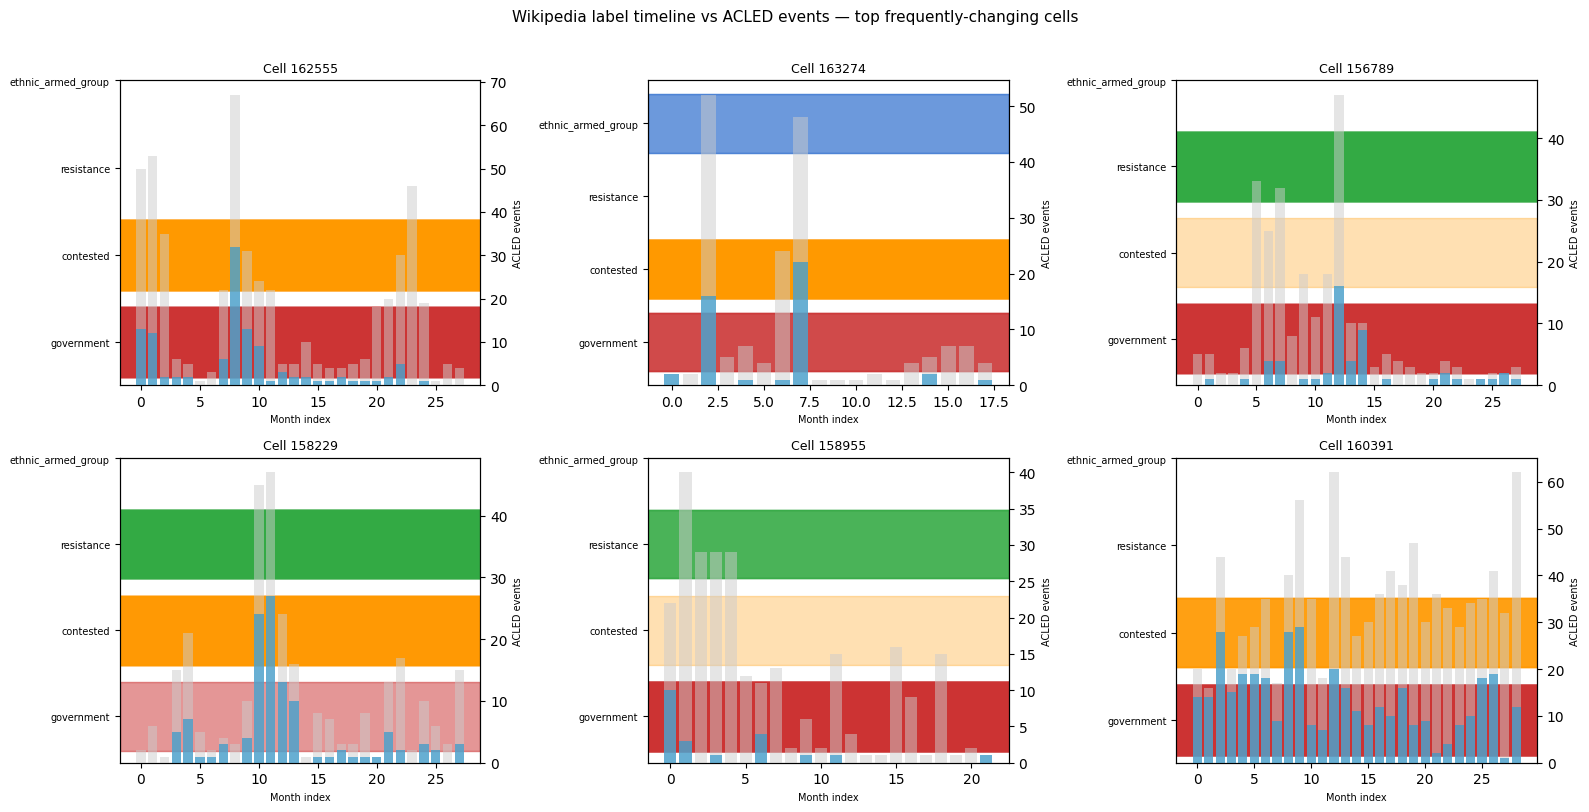

In [11]:
# ── Focus: government → contested transitions ─────────────────
# These are the most analytically important: junta loses grip
gov_to_cont = change_df[change_df['transition'] == 'government → contested']

print(f'government → contested transitions: {len(gov_to_cont)}')
if len(gov_to_cont) > 0:
    print(f'  Mean ACLED events 3mo before: {gov_to_cont["before_events"].mean():.1f}')
    print(f'  Mean ACLED events at/after:   {gov_to_cont["after_events"].mean():.1f}')
    print(f'  Mean Anti-junta delta:        {gov_to_cont["antijunta_delta"].mean():.1f}')
    print(f'  Cells with rising Anti-junta: '
          f'{(gov_to_cont["antijunta_delta"] > 0).mean():.1%}')

print()
# ── Focus: contested → government (junta recapture) ───────────
cont_to_gov = change_df[change_df['transition'] == 'contested → government']

print(f'contested → government transitions: {len(cont_to_gov)}')
if len(cont_to_gov) > 0:
    print(f'  Mean ACLED events 3mo before: {cont_to_gov["before_events"].mean():.1f}')
    print(f'  Mean ACLED events at/after:   {cont_to_gov["after_events"].mean():.1f}')

# ── Timeline plot for top changing cells ──────────────────────
top_change_cells = change_df['priogrid_gid'].value_counts().head(6).index.tolist()

if top_change_cells:
    fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharey=False)
    axes = axes.flatten()

    status_num = {'government': 0, 'contested': 1, 'resistance': 2, 'ethnic_armed_group': 3}

    for idx, cell in enumerate(top_change_cells):
        ax = axes[idx]
        cell_wiki = wiki[wiki['priogrid_gid'] == cell].sort_values('year_month')
        cell_acled = (
            acled[acled['priogrid_gid'] == cell]
                 .groupby('year_month')
                 .agg(n_events=('event_id_cnty', 'count'),
                      n_antijunta=('side', lambda x: (x == 'Anti-junta').sum()))
                 .reset_index()
        )

        ax2 = ax.twinx()
        if len(cell_acled) > 0:
            ax2.bar(range(len(cell_acled)), cell_acled['n_events'],
                    color='#CCCCCC', alpha=0.5, label='ACLED events')
            ax2.bar(range(len(cell_acled)), cell_acled['n_antijunta'],
                    color='#3399CC', alpha=0.7, label='Anti-junta')
            ax2.set_ylabel('ACLED events', fontsize=7)

        for _, wrow in cell_wiki.iterrows():
            ax.axhspan(
                status_num.get(wrow['control_status'], 0) - 0.4,
                status_num.get(wrow['control_status'], 0) + 0.4,
                alpha=0.3,
                color=WIKI_COLOURS.get(wrow['control_status'], '#999999')
            )

        ax.set_yticks(list(status_num.values()))
        ax.set_yticklabels(list(status_num.keys()), fontsize=7)
        ax.set_title(f'Cell {cell}', fontsize=9)
        ax.set_xlabel('Month index', fontsize=7)

    plt.suptitle('Wikipedia label timeline vs ACLED events — top frequently-changing cells',
                 fontsize=11, y=1.01)
    plt.tight_layout()
    plt.show()

## 7. Analysis 4 — Admin1 Regional Alignment

Each admin1 region has a characteristic actor mix in ACLED (Sagaing = PDF heartland, Rakhine = AA, Kachin = KIA, etc.).  
Wikipedia labels should reflect this: Rakhine cells → `ethnic_armed_group`, Sagaing cells → `resistance` or `contested`.

In [12]:
# ── Join admin1 into the panel (from ACLED cell-month aggregation) ─
# For cells with no ACLED events, admin1 will be null — fill from ACLED historical
cell_admin = (
    acled.groupby('priogrid_gid')['admin1']
         .agg(lambda x: x.value_counts().index[0] if len(x) > 0 else None)
         .reset_index()
         .rename(columns={'admin1': 'admin1_acled'})
)
panel_adm = panel.merge(cell_admin, on='priogrid_gid', how='left')

# ── Wikipedia label distribution by admin1 ────────────────────
adm_wiki = (
    panel_adm[panel_adm['admin1_acled'].notna()]
             .groupby(['admin1_acled', 'control_status'])
             .size()
             .unstack(fill_value=0)
)
# Normalise to row %
adm_wiki_pct = adm_wiki.div(adm_wiki.sum(axis=1), axis=0) * 100
adm_wiki_pct['total'] = adm_wiki.sum(axis=1)
adm_wiki_pct = adm_wiki_pct.sort_values('total', ascending=False).head(12)

print('Wikipedia label distribution (%) by admin1 region (top 12 by cell-month count):')
print(adm_wiki_pct.round(1).to_string())

Wikipedia label distribution (%) by admin1 region (top 12 by cell-month count):
control_status  contested  ethnic_armed_group  government  resistance  total
admin1_acled                                                                
Sagaing              24.6                 0.0        64.4        11.0    691
Kachin               10.5                41.8        47.6         0.0    588
Shan-South            1.3                 6.6        90.5         1.6    377
Magway               32.4                 0.0        67.6         0.0    377
Shan-North           32.3                30.5        37.1         0.0    334
Rakhine              13.3                 0.0        31.7        55.0    331
Ayeyarwady            0.0                 0.0       100.0         0.0    319
Mandalay              9.3                 0.0        83.9         6.8    311
Chin                 22.7                26.4         4.8        46.2    273
Shan-East             0.0                 9.5        90.5         0.0    

In [13]:
# ── ACLED dominant actor group by admin1 ──────────────────────
adm_acled = (
    acled[acled['side'].isin(['Pro-junta', 'Anti-junta'])]
         .groupby(['admin1', 'actor_group'])
         .size()
         .reset_index(name='n')
         .sort_values('n', ascending=False)
         .groupby('admin1')
         .head(3)
)
top_regions = acled['admin1'].value_counts().head(12).index.tolist()
print('Top 3 ACLED actor_groups per admin1 (overlap window):')
for region in top_regions:
    actors = adm_acled[adm_acled['admin1'] == region]
    actor_str = '  |  '.join(f"{r['actor_group']} ({r['n']})" for _, r in actors.iterrows())
    print(f'  {region:<20} {actor_str}')

Top 3 ACLED actor_groups per admin1 (overlap window):
  Sagaing              Tatmadaw (3509)  |  People's Defence Force (1902)  |  Kachin Independence Army (KIA) (93)
  Magway               Tatmadaw (2159)  |  People's Defence Force (1374)  |  Arakan Army (AA) (62)
  Mandalay             Tatmadaw (2358)  |  People's Defence Force (1025)  |  TNLA (55)
  Rakhine              Tatmadaw (2647)  |  Arakan Army (AA) (927)  |  ARSA (64)
  Shan-North           Tatmadaw (1876)  |  TNLA (384)  |  MNDAA (287)
  Tanintharyi          Tatmadaw (1250)  |  People's Defence Force (589)  |  Karen National Liberation Army (KNLA) (179)
  Bago-East            Tatmadaw (1558)  |  People's Defence Force (305)  |  Karen National Liberation Army (KNLA) (131)
  Kachin               Tatmadaw (1150)  |  Kachin Independence Army (KIA) (594)  |  People's Defence Force (31)
  Kayin                Tatmadaw (1167)  |  Karen National Liberation Army (KNLA) (391)  |  People's Defence Force (54)
  Bago-West            Tat

In [14]:
# ── Heatmap: admin1 × Wikipedia label ─────────────────────────
plot_regions = adm_wiki_pct.drop(columns='total').index.tolist()
plot_statuses = ['government', 'ethnic_armed_group', 'contested', 'resistance']
plot_statuses = [s for s in plot_statuses if s in adm_wiki_pct.columns]

z = adm_wiki_pct.loc[plot_regions, plot_statuses].values

fig = go.Figure(go.Heatmap(
    z=z,
    x=[s.replace('_', ' ').title() for s in plot_statuses],
    y=plot_regions,
    colorscale='RdYlGn_r',
    text=np.round(z, 1),
    texttemplate='%{text}%',
    colorbar=dict(title='% of\ncell-months'),
))
fig.update_layout(
    title='Wikipedia Label Distribution (%) by Admin1 Region',
    xaxis_title='Wikipedia control_status',
    yaxis_title='Admin1 (state/region)',
    width=750, height=600,
    yaxis=dict(autorange='reversed')
)
fig.show()

## 8. Analysis 5 — Actor Confusion Matrix

For each cell-month: identify the dominant ACLED `actor_group` (most events from non-Unmapped, non-Civilian actors), then cross-tabulate against the Wikipedia label.  
Off-diagonal cells are disagreements worth explaining.

In [15]:
# ── Build confusion matrix ─────────────────────────────────────
conf_data = panel[
    panel['dominant_actor_group'].notna() &
    (~panel['dominant_actor_group'].isin(['Civilians', 'Protesters', 'Unmapped']))
].copy()

# Keep actor groups with enough events to be meaningful
min_events = 30
valid_actors = (
    conf_data['dominant_actor_group'].value_counts()
    [lambda x: x >= min_events].index.tolist()
)
conf_data = conf_data[conf_data['dominant_actor_group'].isin(valid_actors)]

conf_matrix = pd.crosstab(
    conf_data['dominant_actor_group'],
    conf_data['control_status'],
    margins=True
)

print(f'Confusion matrix (raw counts)  —  rows=dominant ACLED actor, cols=Wikipedia label')
print(conf_matrix.to_string())

Confusion matrix (raw counts)  —  rows=dominant ACLED actor, cols=Wikipedia label
control_status                         contested  ethnic_armed_group  government  resistance   All
dominant_actor_group                                                                              
Arakan Army (AA)                              12                   2           5          42    61
Chinland Council                              11                   8           4          15    38
Kachin Independence Army (KIA)                23                  24          28           2    77
Karen National Liberation Army (KNLA)         32                   0          35           0    67
People's Defence Force                       117                   2         414           8   541
Tatmadaw                                     535                 138        1463         187  2323
All                                          730                 174        1949         254  3107


In [16]:
# ── Normalised by row (given dominant actor, what does Wikipedia say?) ─
conf_norm = pd.crosstab(
    conf_data['dominant_actor_group'],
    conf_data['control_status'],
    normalize='index'
) * 100

# Sort rows by total event count (most common actors first)
actor_order = (
    conf_data['dominant_actor_group'].value_counts()
    .reindex(conf_norm.index).sort_values(ascending=False).index.tolist()
)
status_order_conf = ['government', 'contested', 'ethnic_armed_group', 'resistance']
status_order_conf = [s for s in status_order_conf if s in conf_norm.columns]
conf_norm = conf_norm.reindex(index=actor_order, columns=status_order_conf)

print('Confusion matrix (row-normalised %) — given dominant ACLED actor, Wikipedia says:')
print(conf_norm.round(1).to_string())

# ── Heatmap ────────────────────────────────────────────────────
fig = go.Figure(go.Heatmap(
    z=conf_norm.values,
    x=[s.replace('_', ' ').title() for s in conf_norm.columns],
    y=conf_norm.index.tolist(),
    colorscale='Blues',
    text=np.round(conf_norm.values, 1),
    texttemplate='%{text}%',
    colorbar=dict(title='% of\ncell-months'),
    zmin=0, zmax=100
))
fig.update_layout(
    title='Actor Confusion Matrix (row-normalised)<br>'
          '<sup>Given dominant ACLED actor_group in cell-month → what does Wikipedia label?</sup>',
    xaxis_title='Wikipedia control_status',
    yaxis_title='Dominant ACLED actor_group',
    width=750, height=550,
    yaxis=dict(autorange='reversed')
)
fig.show()

Confusion matrix (row-normalised %) — given dominant ACLED actor, Wikipedia says:
control_status                         government  contested  ethnic_armed_group  resistance
dominant_actor_group                                                                        
Tatmadaw                                     63.0       23.0                 5.9         8.0
People's Defence Force                       76.5       21.6                 0.4         1.5
Kachin Independence Army (KIA)               36.4       29.9                31.2         2.6
Karen National Liberation Army (KNLA)        52.2       47.8                 0.0         0.0
Arakan Army (AA)                              8.2       19.7                 3.3        68.9
Chinland Council                             10.5       28.9                21.1        39.5


In [17]:
# ── Disagreement spotlight: cases where ACLED and Wikipedia diverge ─
# Expected alignments:
EXPECTED = {
    'Tatmadaw':                              'government',
    "People's Defence Force":                'resistance',
    'Arakan Army (AA)':                      'ethnic_armed_group',
    'Kachin Independence Army (KIA)':        'ethnic_armed_group',
    'Karen National Liberation Army (KNLA)': 'ethnic_armed_group',
    'TNLA':                                  'ethnic_armed_group',
    'MNDAA':                                 'ethnic_armed_group',
    'Karenni Army':                          'ethnic_armed_group',
    'KNDF':                                  'ethnic_armed_group',
    'Chinland Council':                      'ethnic_armed_group',
}

print('Agreement rate: does Wikipedia label match expected for ACLED dominant actor?')
print()
for actor, expected_label in EXPECTED.items():
    sub = conf_data[conf_data['dominant_actor_group'] == actor]
    if len(sub) == 0:
        print(f'  {actor:<42}  no data')
        continue
    agree_rate = (sub['control_status'] == expected_label).mean()
    top_wiki = sub['control_status'].value_counts().head(3).to_dict()
    bar = '█' * int(agree_rate * 20)
    print(f'  {actor:<42}  agree={agree_rate:.1%}  {bar}')
    print(f'  {"":<42}  Wikipedia says: {top_wiki}')

Agreement rate: does Wikipedia label match expected for ACLED dominant actor?

  Tatmadaw                                    agree=63.0%  ████████████
                                              Wikipedia says: {'government': 1463, 'contested': 535, 'resistance': 187}
  People's Defence Force                      agree=1.5%  
                                              Wikipedia says: {'government': 414, 'contested': 117, 'resistance': 8}
  Arakan Army (AA)                            agree=3.3%  
                                              Wikipedia says: {'resistance': 42, 'contested': 12, 'government': 5}
  Kachin Independence Army (KIA)              agree=31.2%  ██████
                                              Wikipedia says: {'government': 28, 'ethnic_armed_group': 24, 'contested': 23}
  Karen National Liberation Army (KNLA)       agree=0.0%  
                                              Wikipedia says: {'government': 35, 'contested': 32}
  TNLA                          

## 9. Summary — Overlap Assessment

Consolidated view of how well the two sources agree across region, actor, and time.

In [18]:
# ── Coverage statistics ────────────────────────────────────────
total_wiki_cells = wiki['priogrid_gid'].nunique()
acled_cells      = acled['priogrid_gid'].nunique()
overlap_cells    = len(set(wiki['priogrid_gid']) & set(acled['priogrid_gid']))

total_wiki_cm    = len(wiki)
overlap_cm       = panel['has_acled'].sum()

print('=' * 55)
print('OVERLAP ASSESSMENT SUMMARY')
print('=' * 55)
print()
print('── Spatial coverage ──')
print(f'  Wikipedia-labeled cells:          {total_wiki_cells}')
print(f'  ACLED active cells (same window): {acled_cells}')
print(f'  Cells in both sources:            {overlap_cells}  '
      f'({overlap_cells/total_wiki_cells:.1%} of Wikipedia cells)')

print()
print('── Cell-month coverage ──')
print(f'  Total Wikipedia cell-months:      {total_wiki_cm:,}')
print(f'  Cell-months with ACLED events:    {overlap_cm:,}  '
      f'({overlap_cm/total_wiki_cm:.1%})')

print()
print('── Actor-side purity (key labels) ──')
for label in ['government', 'resistance', 'ethnic_armed_group', 'contested']:
    sub = has_events[has_events['control_status'] == label]
    if len(sub) == 0:
        continue
    pj  = sub['pct_projunta'].median()
    aj  = sub['pct_antijunta'].median()
    both = sub['has_both_sides'].mean()
    print(f'  {label:<22} '
          f'pro-junta={pj:.0%}  anti-junta={aj:.0%}  '
          f'both_sides={both:.0%}')

print()
print('── Control signal placement ──')
contested_sig_rate = panel[panel['control_status'] == 'contested']['control_signals'].mean()
govt_sig_rate      = panel[panel['control_status'] == 'government']['control_signals'].mean()
print(f'  Mean control signals/month in contested cells: {contested_sig_rate:.3f}')
print(f'  Mean control signals/month in government cells: {govt_sig_rate:.3f}')
if govt_sig_rate > 0:
    print(f'  Ratio (contested/government): {contested_sig_rate/govt_sig_rate:.1f}×')

print()
print('── Label change temporal lead ──')
if len(gov_to_cont) > 0:
    frac_rising = (gov_to_cont['antijunta_delta'] > 0).mean()
    print(f'  government→contested transitions:  {len(gov_to_cont)}')
    print(f'  Fraction where Anti-junta events increased: {frac_rising:.0%}')

print()
print('── Thesis implications ──')
print('  Use these results to:')
print('  1. Justify Wikipedia as a valid ground-truth source')
print('  2. Quantify the lag between ACLED conflict signal and Wikipedia label update')
print('  3. Flag low-agreement cells as uncertain labels in the model')
print('  4. Show that contested zones are independently confirmed by ACLED control signals')

OVERLAP ASSESSMENT SUMMARY

── Spatial coverage ──
  Wikipedia-labeled cells:          185
  ACLED active cells (same window): 254
  Cells in both sources:            177  (95.7% of Wikipedia cells)

── Cell-month coverage ──
  Total Wikipedia cell-months:      5,238
  Cell-months with ACLED events:    3,398  (64.9%)

── Actor-side purity (key labels) ──
  government             pro-junta=67%  anti-junta=17%  both_sides=51%
  resistance             pro-junta=67%  anti-junta=8%  both_sides=41%
  ethnic_armed_group     pro-junta=69%  anti-junta=5%  both_sides=38%
  contested              pro-junta=56%  anti-junta=23%  both_sides=67%

── Control signal placement ──
  Mean control signals/month in contested cells: 0.146
  Mean control signals/month in government cells: 0.036
  Ratio (contested/government): 4.1×

── Label change temporal lead ──
  government→contested transitions:  12
  Fraction where Anti-junta events increased: 58%

── Thesis implications ──
  Use these results to:
  1. J